# 04 · Forward Model — SG-Supervised Surrogate

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/04_forward_surrogate.ipynb)

The forward model. A pure-physics PINN cannot reproduce diode I–V (the terminal current is a numerically-fragile derived quantity — see `docs/forward_model_reframe.md`). Instead we train a **differentiable surrogate** supervised by the SG oracle. It reproduces I–V to a few percent across 13 orders of magnitude, in seconds.

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.12.0+cu130


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)

from bayespinn_inv.surrogate import (
    SymlogTransform, Normalizer, IVSurrogate, IVSurrogateConfig,
    build_sg_dataset, train_surrogate, SurrogateEnsemble)
symlog = SymlogTransform(I0=1e-6)


## Build an SG-labelled dataset and train one surrogate

In [3]:

train_levels = np.geomspace(5e20, 5e22, 11)
profiles = [step(L) for L in train_levels]
biases = np.linspace(0.0, 0.6, 13)
X, Y = build_sg_dataset(profiles, biases, scaling, sg, symlog)
norm = Normalizer.fit(X)
net = IVSurrogate(IVSurrogateConfig(doping_dim=N_ANCHOR, hidden=128, n_layers=3, seed=0))
hist = train_surrogate(net, X, Y, norm, epochs=2500, lr=2e-3)
print(f"trained {net.num_parameters():,} params, final MSE={hist[-1]:.4f}")


trained 35,457 params, final MSE=0.0016


## Held-out forward accuracy: surrogate vs SG

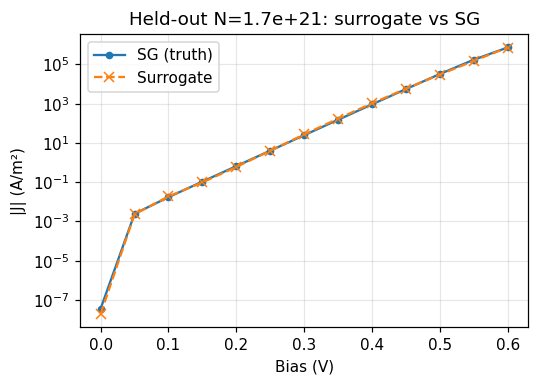

median relative I-V error (V≥0.1): 9.0%


In [4]:

ens = SurrogateEnsemble([net], norm, symlog)
test_L = 1.7e21   # not in the training grid
C = step(test_L)
pred = ens.predict(scaling.doping_to_net_input(C), biases/VT)
Isg = sg_iv(C, biases)
plt.figure(figsize=(5,3.6))
plt.semilogy(biases, np.abs(Isg), "o-", label="SG (truth)", ms=4)
plt.semilogy(biases, np.abs(pred.mean_current), "x--", label="Surrogate")
plt.xlabel("Bias (V)"); plt.ylabel("|J| (A/m²)"); plt.legend()
plt.title(f"Held-out N=%.1e: surrogate vs SG" % test_L)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
rel = np.abs(pred.mean_current[biases>=0.1]-Isg[biases>=0.1])/np.abs(Isg[biases>=0.1])
print(f"median relative I-V error (V≥0.1): {np.median(rel):.1%}")
